(128,)
-1.479999852
1.479999852
-1.479999852
1.479999852
(64, 100)


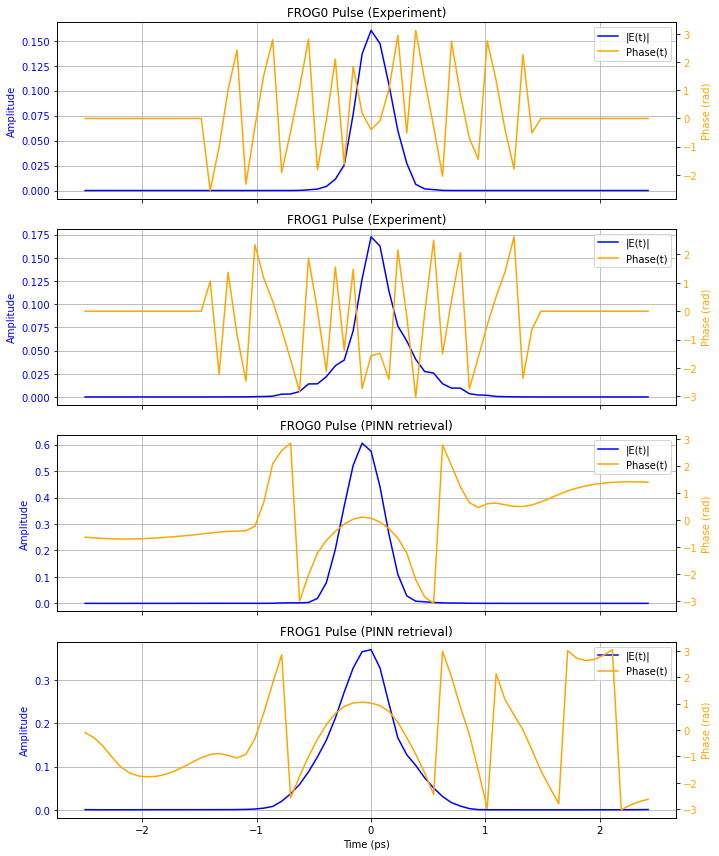

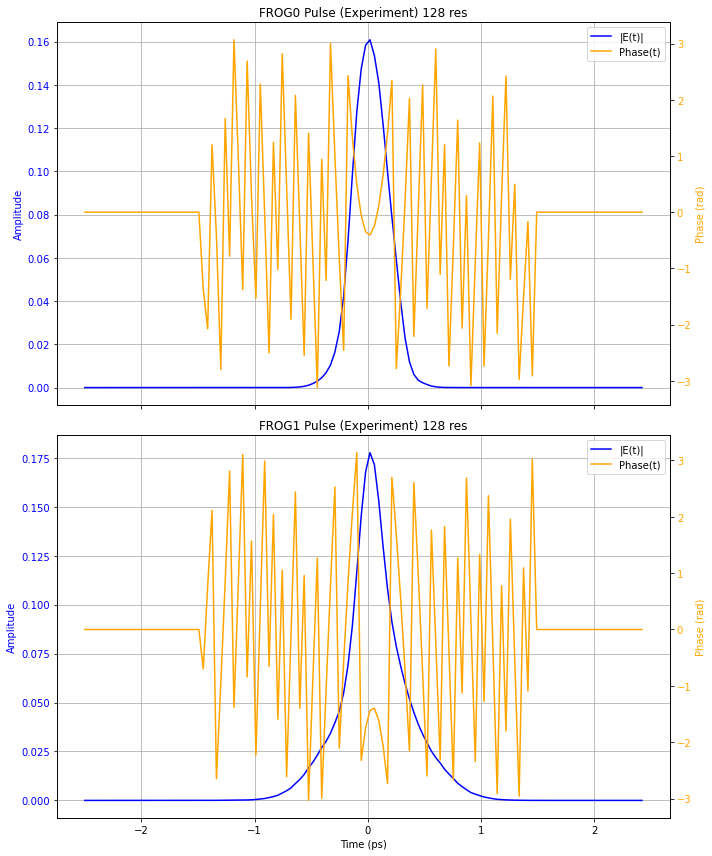

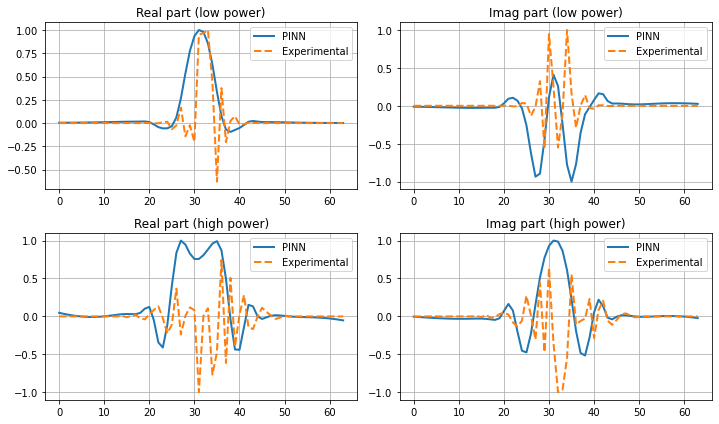

<class 'dict'>
Keys in the pickle file: dict_keys(['epoch_ax', 'loss_log', 'D', 'N2'])


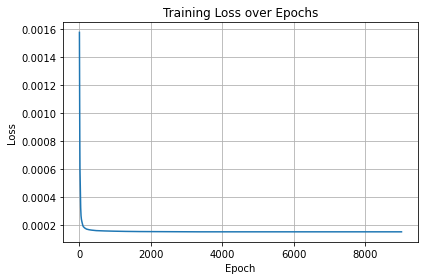

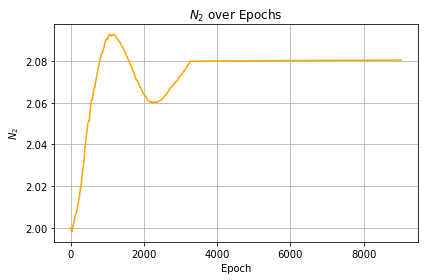

In [4]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.io import loadmat
from scipy.interpolate import interp1d



FROG_8nm = loadmat('FROG_data_8nm_pad2_6.mat')
FROG_3mw = loadmat('FROG_data_3mw_padmatch2_6.mat')

et_ret_8nm = FROG_8nm['et_ret'].squeeze()
et_ret_3mw = FROG_3mw['et_ret'].squeeze()

#print(et_ret_3mw.dtype)

Isig_8nm = FROG_8nm['Isig'].squeeze()
Isig_3mw = FROG_3mw['Isig'].squeeze()



phase_ret_8nm = FROG_8nm['phase_ret'].squeeze()
phase_ret_3mw = FROG_3mw['phase_ret'].squeeze()

t_exp_8nm = FROG_8nm['t_exp'].squeeze()
t_exp_3mw = FROG_3mw['t_exp'].squeeze()

t_exp_8nm = t_exp_8nm*pow(10,12)
t_exp_3mw = t_exp_3mw*pow(10,12)


print(t_exp_8nm.shape)

print(t_exp_8nm[0])
print(t_exp_8nm[-1])

print(t_exp_3mw[0])
print(t_exp_3mw[-1])

#path = '/Ultrafast-Photonics-Research-Group/Ultrafast-Photonics-Research-Group/PIFROG/PI_FROG_TransferModel/frog_data'
path = '../frog_data'

u0p = np.load(path + '/u0p.npy').squeeze()
v0p = np.load(path + '/v0p.npy').squeeze()
u1p = np.load(path + '/u1p.npy').squeeze()
v1p = np.load(path + '/v1p.npy').squeeze()
pinn_t = np.load(path + '/pinn_t.npy').squeeze()


pinn_t_128 = np.linspace(pinn_t[0], pinn_t[-1], 128)

print(u0p.shape)

# If et_ret_8nm is complex, interpolate real and imag parts separately\\

#interp_real = interp1d(orig_t, np.real(orig_signal), kind='linear', bounds_error=False, fill_value=0)

def complex_interp(orig_t, orig_signal, target_t):
    interp_real = interp1d(orig_t, np.real(orig_signal), kind='linear', fill_value=0, bounds_error=False)
    interp_imag = interp1d(orig_t, np.imag(orig_signal), kind='linear', fill_value=0, bounds_error=False)
    return interp_real(target_t) + 1j * interp_imag(target_t)

def real_interp(orig_t, orig_signal, target_t):
    interp_real = interp1d(orig_t, orig_signal, kind='linear', fill_value=0, bounds_error=False)
    #interp_imag = interp1d(orig_t, np.imag(orig_signal), kind='cubic', fill_value="extrapolate")
    return interp_real(target_t)

# Interpolate both signals onto pinn_t
et_ret_8nm_interp = complex_interp(t_exp_8nm, et_ret_8nm, pinn_t)
et_ret_3mw_interp = complex_interp(t_exp_3mw, et_ret_3mw, pinn_t)

u_real0 = np.real(et_ret_8nm_interp)
v_imag0 = np.imag(et_ret_8nm_interp)
I0 = u_real0**2 + v_imag0**2

phase0 = np.arctan2(v_imag0, u_real0) 

u_real1 = np.real(et_ret_3mw_interp)
v_imag1 = np.imag(et_ret_3mw_interp)
I1 = u_real1**2 + v_imag1**2

phase1 = np.arctan2(v_imag1, u_real1) 


et_ret_8nm_128 = real_interp(t_exp_8nm, et_ret_8nm, pinn_t_128)
et_ret_3mw_128 = real_interp(t_exp_3mw, et_ret_3mw, pinn_t_128)

u_real0128 = np.real(et_ret_8nm_128)
v_imag0128 = np.imag(et_ret_8nm_128)
I0128 = u_real0128**2 + v_imag0128**2

phase0128 = np.arctan2(v_imag0128, u_real0128) 

u_real1_128 = np.real(et_ret_3mw_128)
v_imag1_128 = np.imag(et_ret_3mw_128)
I1_128 = u_real1_128**2 + v_imag1_128**2

phase1_128 = np.arctan2(v_imag1_128, u_real1_128) 






u0 = u0p[:,0]
v0 = v0p[:,0]
u1 = u1p[:,-1]
v1 = v1p[:,-1]

phase0sim = np.arctan2(v0, u0)
phase1sim = np.arctan2(v1, u1)

I0sim = u0**2 + v0**2
I1sim = u1**2 + v1**2









#phase_interp_8nm = real_interp(t_exp_8nm, phase_ret_8nm, pinn_t)
#phase_interp_3mw = real_interp(t_exp_3mw, phase_ret_3mw, pinn_t)

#Isig_interp_8nm = real_interp(t_exp_8nm, Isig_8nm, pinn_t)
#Isig_interp_3mw = real_interp(t_exp_3mw, Isig_3mw, pinn_t)



fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

def plot_amp_phase(ax, time, amplitude, phase, title):
    ax_amp = ax
    ax_amp.plot(time, amplitude, color='blue', label='|E(t)|')
    ax_amp.set_ylabel('Amplitude', color='blue')
    ax_amp.tick_params(axis='y', labelcolor='blue')
    ax_amp.grid(True)
    ax_amp.set_title(title)

    ax_phase = ax_amp.twinx()
    ax_phase.plot(time, phase, color='orange', label='Phase(t)')
    ax_phase.set_ylabel('Phase (rad)', color='orange')
    ax_phase.tick_params(axis='y', labelcolor='orange')

    # Combine legends from both axes
    lines_amp, labels_amp = ax_amp.get_legend_handles_labels()
    lines_phase, labels_phase = ax_phase.get_legend_handles_labels()
    ax_amp.legend(lines_amp + lines_phase, labels_amp + labels_phase, loc='upper right')

# Plot experimental / original
plot_amp_phase(axes[0], pinn_t, np.abs(I0), phase0, 'FROG0 Pulse (Experiment)')
plot_amp_phase(axes[1], pinn_t, np.abs(I1), phase1, 'FROG1 Pulse (Experiment)')

# Plot simulated
plot_amp_phase(axes[2], pinn_t, I0sim, phase0sim, 'FROG0 Pulse (PINN retrieval)')
plot_amp_phase(axes[3], pinn_t, I1sim, phase1sim, 'FROG1 Pulse (PINN retrieval)')

axes[-1].set_xlabel('Time (ps)')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2,1, figsize=(10,12), sharex = True)

# Plot experimental / original
plot_amp_phase(axes[0], pinn_t_128, np.abs(I0128), phase0128, 'FROG0 Pulse (Experiment) 128 res')
plot_amp_phase(axes[1], pinn_t_128, np.abs(I1_128), phase1_128, 'FROG1 Pulse (Experiment) 128 res')
axes[-1].set_xlabel('Time (ps)')

plt.tight_layout()
plt.show()



# Normalize helper
def normalize(x):
    return x / np.max(np.abs(x))

# Normalize all signals
u0_norm = normalize(u0)
u_real0_norm = normalize(u_real0)

v0_norm = normalize(v0)
v_imag0_norm = normalize(v_imag0)

u1_norm = normalize(u1)
u_real1_norm = normalize(u_real1)

v1_norm = normalize(v1)
v_imag1_norm = normalize(v_imag1)

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
axs[0, 0].plot(u0_norm, label='PINN', linewidth=2)
axs[0, 0].plot(u_real0_norm, '--', label='Experimental', linewidth=2)
axs[0, 0].set_title("Real part (low power)")
axs[0, 0].legend()

axs[0, 1].plot(v0_norm, label='PINN', linewidth=2)
axs[0, 1].plot(v_imag0_norm, '--', label='Experimental', linewidth=2)
axs[0, 1].set_title("Imag part (low power)")
axs[0, 1].legend()

axs[1, 0].plot(u1_norm, label='PINN', linewidth=2)
axs[1, 0].plot(u_real1_norm, '--', label='Experimental', linewidth=2)
axs[1, 0].set_title("Real part (high power)")
axs[1, 0].legend()

axs[1, 1].plot(v1_norm, label='PINN', linewidth=2)
axs[1, 1].plot(v_imag1_norm, '--', label='Experimental', linewidth=2)
axs[1, 1].set_title("Imag part (high power)")
axs[1, 1].legend()

for ax in axs.flat:
    ax.grid(True)

plt.tight_layout()
plt.show()










with open('PIFROG_BaseModel_logger_data.pkl', 'rb') as f:
    data = pickle.load(f)
print(type(data))

if isinstance(data, dict):
    print("Keys in the pickle file:", data.keys())


saving = False
# Extract values
epoch_ax = data['epoch_ax']
loss_log = data['loss_log']
N2 = data['N2']

# Optional: Create a folder to save
save_dir = 'logloss_outputs'
os.makedirs(save_dir, exist_ok=True)

if saving:
    np.save(os.path.join(save_dir, 'epoch_ax.npy'), epoch_ax)
    np.save(os.path.join(save_dir, 'loss_log.npy'), loss_log)
    np.save(os.path.join(save_dir, 'N2.npy'), N2)

# Plot loss_log
plt.figure(figsize=(6, 4))
plt.plot(epoch_ax, loss_log, label='Log Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.tight_layout()

if saving:
    plt.savefig(os.path.join(save_dir, 'loss_log.png'))
plt.show()
plt.close()

# Plot N2
plt.figure(figsize=(6, 4))
plt.plot(epoch_ax, N2, label='N2', color='orange')
plt.xlabel('Epoch')
plt.ylabel('$N_2$')
plt.title('$N_2$ over Epochs')
plt.grid(True)
plt.tight_layout()

if saving:
    plt.savefig(os.path.join(save_dir, 'N2.png'))
plt.show()
plt.close()
